In [1]:
# Step 1: Install necessary libraries
!pip install h5py

# Step 2: Import required libraries
import h5py
import requests
from io import BytesIO
import numpy as np
import pandas as pd

In [2]:
import requests
from io import BytesIO
import h5py

url = "https://github.com/NREL/ReEDS-2.0/raw/refs/heads/main/inputs/load/historic_load_hourly.h5"

# Download
resp = requests.get(url, stream=True, timeout=300)
resp.raise_for_status()

buf = BytesIO()
for chunk in resp.iter_content(chunk_size=1024 * 1024):  # 1 MB chunks
    if chunk:
        buf.write(chunk)

# Rewind buffer
buf.seek(0)

# Detect Git LFS pointer (happens if you didn't get the real file)
head = buf.getvalue()[:200].decode("utf-8", errors="ignore")
if "git-lfs" in head and "spec/v1" in head:
    raise RuntimeError(
        "This looks like a Git LFS pointer, not the real .h5 file bytes. "
        "Best fix: clone the repo with Git LFS enabled (git lfs install; git lfs pull), "
        "or download the actual LFS object from a release asset if available."
    )

# Open HDF5 and inspect
with h5py.File(buf, "r") as f:
    print("Keys:", list(f.keys()))
    for k in f.keys():
        obj = f[k]
        if hasattr(obj, "shape"):
            print(f"  {k}: shape={obj.shape}, dtype={obj.dtype}")
        else:
            print(f"  {k}: group")




Keys: ['columns', 'data', 'index_0', 'index_names']
  columns: shape=(134,), dtype=|S4
  data: shape=(131400, 134), dtype=float64
  index_0: shape=(131400,), dtype=|S30
  index_names: shape=(1,), dtype=|S8


data shape: (131400, 134)
first timestamps: ['2007-01-01T00:00:00-06:00', '2007-01-01T01:00:00-06:00', '2007-01-01T02:00:00-06:00']
last timestamps: ['2023-12-31T21:00:00-06:00', '2023-12-31T22:00:00-06:00', '2023-12-31T23:00:00-06:00']
ERCOT column indices: [91, 92, 93, 94, 95, 96, 98]
Detected 15 weather-year realizations.

Annual energy per weather year (realization):
 realization  annual_energy_MWh
          15        473,190,244
          10        470,272,519
           8        468,819,704
          14        466,804,241
          11        461,425,196
           3        460,864,715
           7        460,864,396
           6        460,862,517
           1        460,857,627
           5        460,855,604
           2        460,854,084
           4        460,841,161
           9        459,484,092
          12        445,111,268
          13        441,942,668


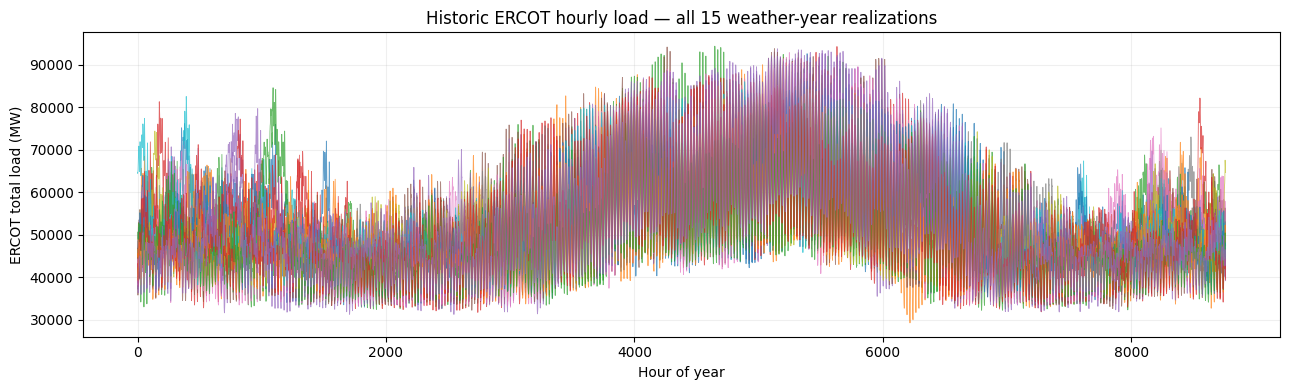

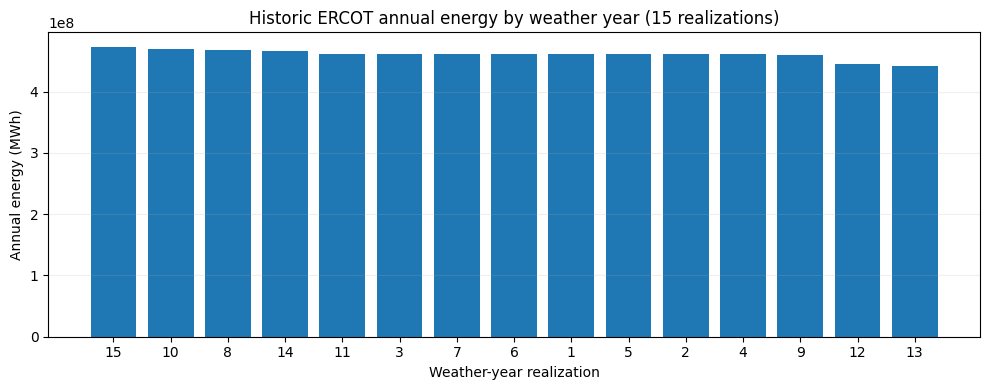

In [3]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ERCOT BA codes you already use
ERCOT_BAs_list = ['p60', 'p61', 'p62', 'p63', 'p64', 'p65', 'p67']
HOURS_PER_YEAR = 8760

# Rewind the BytesIO object to the beginning
buf.seek(0)

with h5py.File(buf, 'r') as f:
    data = f['data'][:]  # (131400, 134)
    cols = [c.decode('utf-8') for c in f['columns'][:]]
    ts = [t.decode('utf-8') for t in f['index_0'][:]]  # datetime strings

print("data shape:", data.shape)
print("first timestamps:", ts[:3])
print("last timestamps:", ts[-3:])

# Map ERCOT BA names to column indices
missing = [ba for ba in ERCOT_BAs_list if ba not in cols]
if missing:
    raise ValueError(f"Missing ERCOT BAs in columns: {missing}")

ercot_idx = [cols.index(ba) for ba in ERCOT_BAs_list]
print("ERCOT column indices:", ercot_idx)

# Compute ERCOT total hourly (MW)
ercot_hourly = data[:, ercot_idx].sum(axis=1)  # (131400,)

# Infer number of realizations and reshape
if len(ercot_hourly) % HOURS_PER_YEAR != 0:
    raise ValueError("Row count not divisible by 8760; cannot split into weather years cleanly.")
R = len(ercot_hourly) // HOURS_PER_YEAR
ercot_real = ercot_hourly.reshape(R, HOURS_PER_YEAR)  # (15, 8760)
print(f"Detected {R} weather-year realizations.")

# Annual energy per realization (MW*h)
annual_energy = ercot_real.sum(axis=1)
df_annual = pd.DataFrame({
    "realization": np.arange(1, R+1),
    "annual_energy_MWh": annual_energy
}).sort_values("annual_energy_MWh", ascending=False)

print("\nAnnual energy per weather year (realization):")
print(df_annual.to_string(index=False, float_format=lambda x: f"{x:,.0f}"))

df_annual.to_csv("historic_ercot_annual_energy_by_weather_year.csv", index=False)

# ---------- Plot A: all 15 realizations (hourly shape) ----------
plt.figure(figsize=(13, 4))
for r in range(R):
    plt.plot(ercot_real[r, :], linewidth=0.6, alpha=0.7)
plt.title("Historic ERCOT hourly load — all 15 weather-year realizations")
plt.xlabel("Hour of year")
plt.ylabel("ERCOT total load (MW)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("historic_ercot_hourly_all_15.png", dpi=200)
plt.show()



# ---------- Plot C: annual totals bar chart ----------
plt.figure(figsize=(10, 4))
plt.bar(df_annual["realization"].astype(str), df_annual["annual_energy_MWh"])
plt.title("Historic ERCOT annual energy by weather year (15 realizations)")
plt.xlabel("Weather-year realization")
plt.ylabel("Annual energy (MWh)")
plt.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("historic_ercot_annual_energy_by_weather_year.png", dpi=200)
plt.show()

 year  annual_energy_MWh  pct_vs_2010
 2007    460,857,627.000        0.004
 2008    460,854,084.000        0.003
 2009    460,864,715.000        0.005
 2010    460,841,161.000        0.000
 2011    460,855,604.000        0.003
 2012    460,862,517.000        0.005
 2013    460,864,396.000        0.005
 2016    468,819,704.000        1.731
 2017    459,484,092.000       -0.294
 2018    470,272,519.000        2.047
 2019    461,425,196.000        0.127
 2020    445,111,268.000       -3.413
 2021    441,942,668.000       -4.101
 2022    466,804,241.000        1.294
 2023    473,190,244.000        2.680


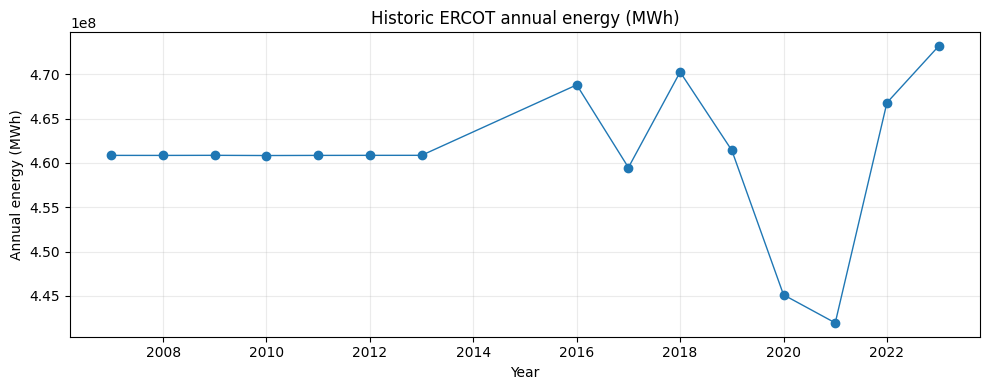

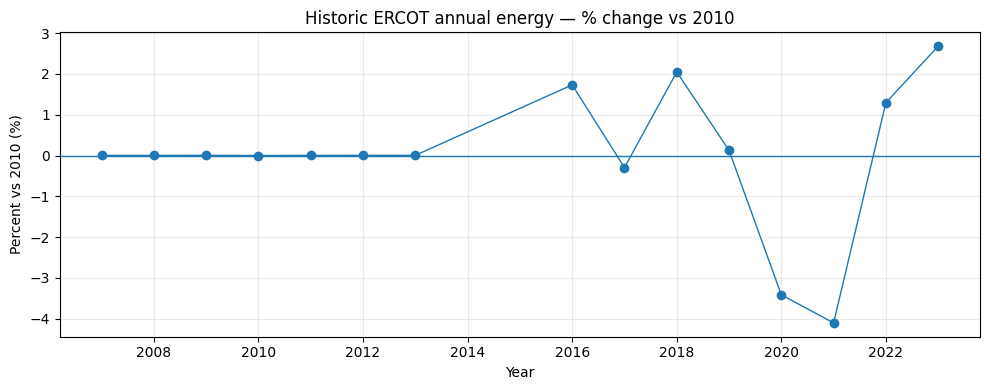

In [4]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ERCOT_BAs_list = ['p60', 'p61', 'p62', 'p63', 'p64', 'p65', 'p67']
BASE_YEAR = 2010

# IMPORTANT: rewind BytesIO before reading with h5py
buf.seek(0)

with h5py.File(buf, 'r') as f:
    data = f['data'][:]  # (131400, 134)
    cols = [c.decode('utf-8') for c in f['columns'][:]]
    ts = [t.decode('utf-8') for t in f['index_0'][:]]  # datetime strings

# Map ERCOT BA columns
missing = [ba for ba in ERCOT_BAs_list if ba not in cols]
if missing:
    raise ValueError(f"Missing ERCOT BAs in columns: {missing}")
ercot_idx = [cols.index(ba) for ba in ERCOT_BAs_list]

# Build dataframe with hourly ERCOT total
dt = pd.to_datetime(ts)  # parses timezone offsets like -06:00
ercot_hourly = data[:, ercot_idx].sum(axis=1)

df = pd.DataFrame({"datetime": dt, "ercot_MW": ercot_hourly}).sort_values("datetime")
df["year"] = df["datetime"].dt.year

# Annual totals (MWh if hourly)
# Fix: Use .reset_index() to convert the 'year' index to a column
annual_df = df.groupby("year")["ercot_MW"].sum().rename("annual_energy_MWh").reset_index()

if BASE_YEAR not in annual_df["year"].values:
    raise KeyError(f"Base year {BASE_YEAR} not found in the timestamps. Available years: {annual_df['year'].tolist()}")

# Fix: Access base year value from the new annual_df DataFrame
base = annual_df[annual_df["year"] == BASE_YEAR]["annual_energy_MWh"].iloc[0]

# Fix: Create the 'out' DataFrame directly from annual_df and add the 'pct_vs_2010' column
out = annual_df.copy()
out["pct_vs_2010"] = ((out["annual_energy_MWh"] / base) - 1) * 100

# The DataFrame should already be sorted by year from reset_index if the original df was sorted,
# but keeping sort_values for robustness.
out = out.sort_values("year")

print(out.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

# Save
out.to_csv("historic_ercot_annual_vs_2010.csv", index=False)

# Plot: annual energy
plt.figure(figsize=(10,4))
plt.plot(out["year"], out["annual_energy_MWh"], marker="o", linewidth=1)
plt.title("Historic ERCOT annual energy (MWh)")
plt.xlabel("Year")
plt.ylabel("Annual energy (MWh)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("historic_ercot_annual_energy.png", dpi=200)
plt.show()

# Plot: percent vs 2010
plt.figure(figsize=(10,4))
plt.plot(out["year"], out["pct_vs_2010"], marker="o", linewidth=1)
plt.axhline(0, linewidth=1)
plt.title("Historic ERCOT annual energy — % change vs 2010")
plt.xlabel("Year")
plt.ylabel("Percent vs 2010 (%)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("historic_ercot_pct_vs_2010.png", dpi=200)
plt.show()

In [5]:
import h5py, pandas as pd

buf.seek(0)
with h5py.File(buf, "r") as f:
    ts = [t.decode("utf-8") for t in f["index_0"][:]]

dt = pd.to_datetime(ts)
print("Min datetime:", dt.min())
print("Max datetime:", dt.max())
print("Years present:", sorted(dt.year.unique()))

Min datetime: 2007-01-01 00:00:00-06:00
Max datetime: 2023-12-31 23:00:00-06:00
Years present: [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


Saved: tx_demand_multipliers_aeo2023.csv


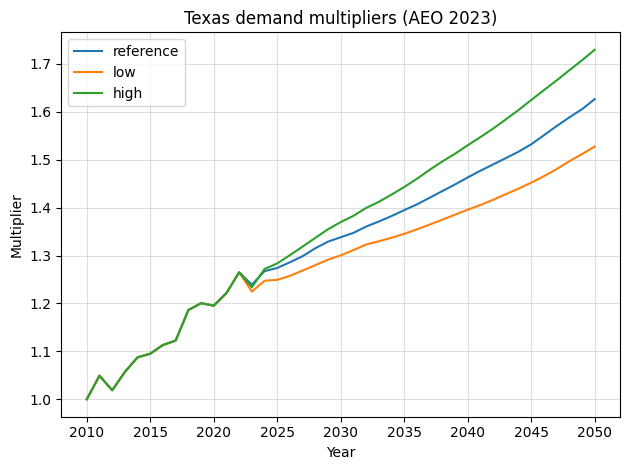

Saved: tx_demand_multiplier_aeo2023.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Inputs ---
urls = {
    "reference": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/load/demand_AEO_2023_reference.csv",
    "low":       "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/load/demand_AEO_2023_low.csv",
    "high":      "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/load/demand_AEO_2023_high.csv",
}
state = "TX"

# --- Load + filter to Texas ---
dfs = []
for scen, url in urls.items():
    df = pd.read_csv(url)
    df = df[df["r"] == state].copy()
    df["scenario"] = scen
    df["year"] = df["year"].astype(int)
    df["multiplier"] = df["multiplier"].astype(float)
    dfs.append(df)

tx = pd.concat(dfs, ignore_index=True).sort_values(["scenario", "year"])

# Optional: save the filtered table
out_csv = "tx_demand_multipliers_aeo2023.csv"
tx.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

# --- Plot 1: multipliers (raw) ---
plt.figure()
for scen in ["reference", "low", "high"]:
    d = tx[tx["scenario"] == scen]
    plt.plot(d["year"], d["multiplier"], label=scen)

plt.title("Texas demand multipliers (AEO 2023)")
plt.xlabel("Year")
plt.ylabel("Multiplier")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()

out_png1 = "tx_demand_multiplier_aeo2023.png"
plt.savefig(out_png1, dpi=200)
plt.show()
print(f"Saved: {out_png1}")





=== LS Envelope (TX) ===
Fit window: 2025–2050  (n=26)
low_mult  = 0.957906  (from low fit)
high_mult = 1.0423 (from high fit)
Equivalent range vs reference: [-4.209%, 4.230%]

Year  ref_multiplier   env_low   env_high
2025      1.274073  1.220442  1.327970
2026      1.285956  1.231825  1.340356
2027      1.298559  1.243897  1.353492
2028      1.315165  1.259804  1.370800
2029      1.328960  1.273019  1.385179
2030      1.338134  1.281806  1.394741
2031      1.347244  1.290532  1.404236
2032      1.360393  1.303128  1.417942
2033      1.370933  1.313224  1.428927
2034      1.382293  1.324106  1.440768
2035      1.394665  1.335958  1.453663
2036      1.406713  1.347499  1.466221
2037      1.420417  1.360626  1.480505
2038      1.434402  1.374022  1.495082
2039      1.448230  1.387268  1.509495
2040      1.462869  1.401291  1.524753
2041      1.476829  1.414663  1.539303
2042      1.490001  1.427280  1.553032
2043      1.503154  1.439879  1.566741
2044      1.516532  1.452695  1.580686


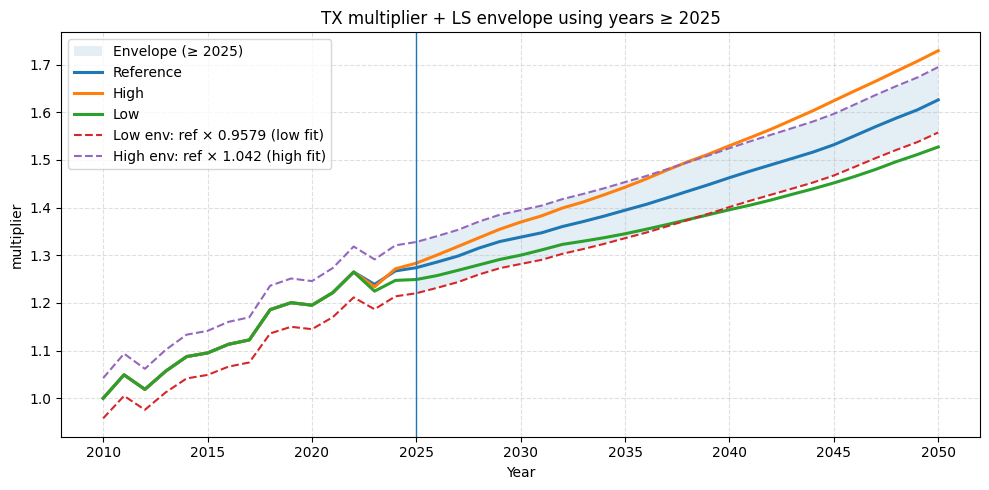

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Helpers ----------
def fit_multiplier_ls(ref: pd.Series, target: pd.Series) -> float:
    """Least-squares scalar m minimizing ||m*ref - target||^2 over aligned years."""
    x = ref.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(x, x))
    if denom == 0:
        return np.nan
    return float(np.dot(x, y) / denom)

def make_tx_df_from_urls(urls: dict, state="TX") -> pd.DataFrame:
    """urls = {'reference':..., 'low':..., 'high':...}"""
    dfs = []
    for scen, url in urls.items():
        df = pd.read_csv(url)
        df = df[df["r"] == state].copy()
        df["scenario"] = scen
        df["year"] = df["year"].astype(int)
        df["multiplier"] = df["multiplier"].astype(float)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True).sort_values(["year", "scenario"])

def envelope_for_tx(df: pd.DataFrame, value_col="multiplier", start_year: int = 2025) -> dict:
    """
    LS envelope using reference as baseline:
      high ~ m_high * reference
      low  ~ m_low  * reference
    """
    piv = (df[["year", "scenario", value_col]]
           .pivot(index="year", columns="scenario", values=value_col)
           .sort_index())

    needed = ["reference", "high", "low"]
    missing = [s for s in needed if s not in piv.columns]
    if missing:
        raise ValueError(f"Missing scenarios: {missing}. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=needed, how="any")
    if len(window) < 2:
        raise ValueError(f"Not enough overlapping years >= {start_year} for '{value_col}'.")

    ref = window["reference"]
    m_high = fit_multiplier_ls(ref, window["high"])
    m_low  = fit_multiplier_ls(ref, window["low"])

    low_mult  = float(np.nanmin([m_high, m_low]))
    high_mult = float(np.nanmax([m_high, m_low]))
    low_ref   = "high" if m_high <= m_low else "low"
    high_ref  = "high" if m_high >= m_low else "low"

    return {
        "value_col": value_col,
        "m_high": m_high,
        "m_low": m_low,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_years_fit": int(len(window)),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_tx_with_envelope(df: pd.DataFrame, value_col="multiplier", start_year: int = 2025, title_suffix=""):
    info = envelope_for_tx(df, value_col=value_col, start_year=start_year)

    piv = (df[["year", "scenario", value_col]]
           .pivot(index="year", columns="scenario", values=value_col)
           .sort_index())

    years = piv.index
    ref_all = piv["reference"]
    env_low  = ref_all * info["low_mult"]
    env_high = ref_all * info["high_mult"]

    # ---- Print ranges (for years >= start_year) ----
    mask = years >= start_year
    yrs = years[mask]

    print("\n=== LS Envelope (TX) ===")
    print(f"Fit window: {info['fit_year_min']}–{info['fit_year_max']}  (n={info['n_years_fit']})")
    print(f"low_mult  = {info['low_mult']:.6g}  (from {info['low_ref']} fit)")
    print(f"high_mult = {info['high_mult']:.6g} (from {info['high_ref']} fit)")
    print(f"Equivalent range vs reference: [{(info['low_mult']-1)*100:.3f}%, {(info['high_mult']-1)*100:.3f}%]")

    print("\nYear  ref_multiplier   env_low   env_high")
    for y in yrs:
        print(f"{int(y):4d}  {ref_all.loc[y]:12.6f}  {env_low.loc[y]:8.6f}  {env_high.loc[y]:8.6f}")

    print("\nEnvelope bounds over years ≥", start_year)
    print(f"env_low  min/max:  {env_low.loc[yrs].min():.6f} / {env_low.loc[yrs].max():.6f}")
    print(f"env_high min/max:  {env_high.loc[yrs].min():.6f} / {env_high.loc[yrs].max():.6f}")

    # ---- Plot ----
    plt.figure(figsize=(10, 5))

    plt.fill_between(
        yrs,
        env_low.loc[yrs].values,
        env_high.loc[yrs].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )

    plt.plot(years, piv["reference"].values, linewidth=2.2, label="Reference")
    plt.plot(years, piv["high"].values, linewidth=2.2, label="High")
    plt.plot(years, piv["low"].values, linewidth=2.2, label="Low")

    plt.plot(years, env_low.values, "--",
             label=f"Low env: ref × {info['low_mult']:.4g} ({info['low_ref']} fit)")
    plt.plot(years, env_high.values, "--",
             label=f"High env: ref × {info['high_mult']:.4g} ({info['high_ref']} fit)")

    plt.axvline(start_year, linewidth=1)
    plt.title(f"TX {value_col} + LS envelope using years ≥ {start_year}{title_suffix}")
    plt.xlabel("Year")
    plt.ylabel(value_col)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return info, piv, env_low, env_high


# ---------- Run (TX AEO 2023 multipliers) ----------
urls = {
    "reference": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/load/demand_AEO_2023_reference.csv",
    "low":       "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/load/demand_AEO_2023_low.csv",
    "high":      "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/load/demand_AEO_2023_high.csv",
}

tx = make_tx_df_from_urls(urls, state="TX")

info_mult, piv_mult, envL_mult, envH_mult = plot_tx_with_envelope(
    tx, value_col="multiplier", start_year=2025
)


In [8]:
# Load the 'reference' file (full US) to get the df_ref DataFrame
import pandas as pd

# 'urls' dictionary should be defined from a previous cell (e.g., fwAE9zy_WqUz)
ref_url = urls["reference"]
df_ref = pd.read_csv(ref_url)

# Ensure types are clean
df_ref["year"] = pd.to_numeric(df_ref["year"], errors="raise").astype(int)
df_ref["multiplier"] = pd.to_numeric(df_ref["multiplier"], errors="raise").astype(float)

print("df_ref loaded successfully. First 5 rows:")
display(df_ref.head())

df_ref loaded successfully. First 5 rows:


,r,year,multiplier
0,IL,2010,1.000076
1,IL,2011,0.987122
2,IL,2012,0.991686
3,IL,2013,0.979703
4,IL,2014,0.977933


In [9]:
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# REQUIREMENTS / ASSUMPTIONS:
# You already have these from the previous cells:
#   df_ref  : reference multipliers (all regions), columns: ['r','year','multiplier']
#   df_tx_ref : TX-only view of df_ref OR you can filter from df_ref
#   low_mult_fit, high_mult_fit : the scalar bounds you computed from the envelope fit
#
# If your variable names differ, just map them below.
# ------------------------------------------------------------

# ---- 0) Map your existing objects / numbers here ----
# Example names (change to match your notebook):
# df_ref = df_ref
low_mult_fit = info_mult['low_mult'] # Corrected: Assign from info_mult
high_mult_fit = info_mult['high_mult'] # Corrected: Assign from info_mult

TX_REGION = "TX"
FIT_START_YEAR = 2025  # match the year window you used for the envelope fit

# ---- 1) Clean scalar bounds (ensure low < high) ----
low_bound = float(min(low_mult_fit, high_mult_fit))
high_bound = float(max(low_mult_fit, high_mult_fit))

print(f"Envelope scalar bounds (TX scaling vs reference): [{low_bound:.6f}, {high_bound:.6f}]")

# ---- 2) Sampling setup ----
n_samples = 2          # <-- change as needed
seed = 123              # reproducible
rng = np.random.default_rng(seed)

# Uniform sampling between bounds
sampled_scalars = rng.uniform(low_bound, high_bound, size=n_samples).tolist()

# Put in list format (what you asked)
print("sampled_scalars = [")
for x in sampled_scalars:
    print(f"  {x:.8f},")
print("]")

# Save sampling record (optional but helpful)
out_dir = Path("demand_sampling_outputs")
out_dir.mkdir(exist_ok=True)

pd.DataFrame({
    "sample_id": np.arange(1, n_samples + 1),
    "tx_scalar": sampled_scalars,
    "low_bound": low_bound,
    "high_bound": high_bound,
    "seed": seed
}).to_csv(out_dir / "TX_scalar_samples.csv", index=False)

# ---- 3) Build TX reference series from df_ref ----
df_ref = df_ref.copy()
df_ref["year"] = df_ref["year"].astype(int)
df_ref["multiplier"] = df_ref["multiplier"].astype(float)

tx_mask = (df_ref["r"] == TX_REGION)
df_tx_ref = df_ref.loc[tx_mask].copy()

if df_tx_ref.empty:
    raise ValueError("Could not find TX in df_ref['r']. Check region labels in your file.")

# ---- 4) Generate ReEDS-format CSV for each sample ----
def make_sample_file(sample_id: int, tx_scalar: float) -> Path:
    df_out = df_ref.copy()

    # Apply scalar to TX only for years >= FIT_START_YEAR
    m = (df_out["r"] == TX_REGION) & (df_out["year"] >= FIT_START_YEAR)
    df_out.loc[m, "multiplier"] = df_out.loc[m, "multiplier"] * tx_scalar

    # Keep EXACT GitHub format ordering/columns
    df_out = df_out[["r", "year", "multiplier"]].sort_values(["r", "year"]).reset_index(drop=True)

    fpath = out_dir / f"demand_AEO_2023_TXsample_{sample_id:03d}.csv"
    df_out.to_csv(fpath, index=False)
    return fpath

generated_files = []
for i, s in enumerate(sampled_scalars, start=1):
    generated_files.append(make_sample_file(i, s))

print(f"\nGenerated {len(generated_files)} ReEDS-format files in: {out_dir.resolve()}")
print("Example:", generated_files[0])

Envelope scalar bounds (TX scaling vs reference): [0.957906, 1.042303]
sampled_scalars = [
  1.01549417,
  0.96244793,
]

Generated 2 ReEDS-format files in: /content/demand_sampling_outputs
Example: demand_sampling_outputs/demand_AEO_2023_TXsample_001.csv


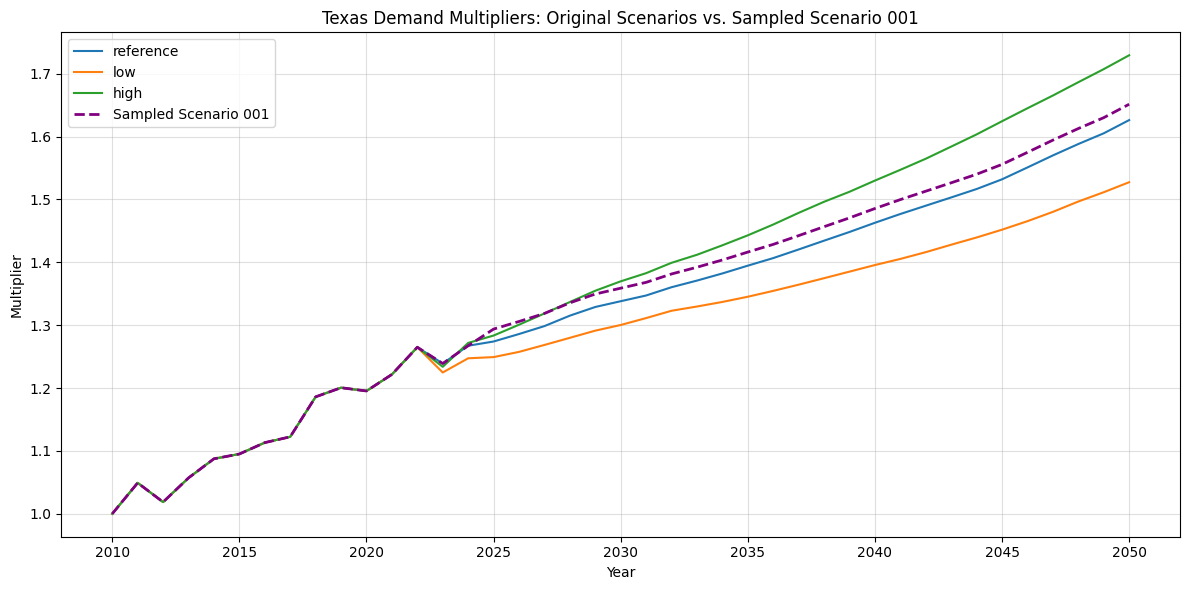

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Choose one of the generated sample files to visualize
sample_file_path = "demand_sampling_outputs/demand_AEO_2023_TXsample_001.csv"
df_sample = pd.read_csv(sample_file_path)

# Filter for Texas data from the sample
df_sample_tx = df_sample[df_sample["r"] == "TX"].copy()
df_sample_tx["scenario"] = "sampled_001" # Add a scenario name for plotting

# Combine with the original tx DataFrame for comparison
# (Assuming 'tx' DataFrame from previous steps is available, which it is based on kernel state)
combined_df = pd.concat([tx, df_sample_tx], ignore_index=True)

# Plotting
plt.figure(figsize=(12, 6))

# Plot original scenarios
for scen in ["reference", "low", "high"]:
    d = combined_df[combined_df["scenario"] == scen]
    plt.plot(d["year"], d["multiplier"], label=scen, linewidth=1.5)

# Plot the sampled scenario
d_sample = combined_df[combined_df["scenario"] == "sampled_001"]
plt.plot(d_sample["year"], d_sample["multiplier"], label="Sampled Scenario 001", linestyle='--', color='purple', linewidth=2)

plt.title("Texas Demand Multipliers: Original Scenarios vs. Sampled Scenario 001")
plt.xlabel("Year")
plt.ylabel("Multiplier")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
from IPython.display import Markdown, display

# info_mult comes from:
# info_mult, piv_mult, envL_mult, envH_mult = plot_tx_with_envelope(tx, value_col="multiplier", start_year=2025)

low_mult  = info_mult["low_mult"]
high_mult = info_mult["high_mult"]

latex_rows = []
latex_rows.append(
    rf"Electricity demand multiplier -- TX (low from {info_mult['low_ref']}, high from {info_mult['high_ref']})"
    rf" & {high_mult:.4f} & {low_mult:.4f} & unitless (multiplier) \\"
)

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Texas electricity demand multiplier bounds (LS envelope, years $\geq$ {info_mult['fit_year_min']})}}
\label{{tab:tx_demand_multiplier_bounds}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))


```latex

\begin{table}[h!]
\centering
\caption{Texas electricity demand multiplier bounds (LS envelope, years $\geq$ 2025)}
\label{tab:tx_demand_multiplier_bounds}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
Electricity demand multiplier -- TX (low from low, high from high) & 1.0423 & 0.9579 & unitless (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [12]:
import numpy as np
import pandas as pd
from pathlib import Path
import zipfile

# ============================================================
# USER INPUTS (your raw GitHub links)
# ============================================================
URL_NREL_REF = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/load/demand_AEO_2023_reference.csv"
URL_MORRIS_DESIGN = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv"
URL_FACTOR_MAP = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv"

TX_REGION = "TX"
START_YEAR = 2025  # apply multiplier only for years >= 2025

OUTDIR = Path("demand_morris_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

ZIP_NAME = "demand_AEO_2023_TX_morris_r5_p6_200files.zip"


# ============================================================
# 1) READ NREL REFERENCE FILE (THIS DEFINES THE EXACT FORMAT)
#    We preserve its exact column names + order.
# ============================================================
df_ref = pd.read_csv(URL_NREL_REF)

# --- hard checks to avoid ReEDS errors ---
required = ["r", "year", "multiplier"]
missing = [c for c in required if c not in df_ref.columns]
if missing:
    raise ValueError(f"NREL reference file missing required columns: {missing}. Found: {list(df_ref.columns)}")

# Preserve EXACT column order as in NREL reference
ref_cols = df_ref.columns.tolist()

# Dtypes / cleanup
df_ref = df_ref.copy()
df_ref["r"] = df_ref["r"].astype(str)
df_ref["year"] = pd.to_numeric(df_ref["year"], errors="raise").astype(int)
df_ref["multiplier"] = pd.to_numeric(df_ref["multiplier"], errors="raise").astype(float)

# Ensure TX exists (avoid silent failures)
if (df_ref["r"] == TX_REGION).sum() == 0:
    raise ValueError(f"Region '{TX_REGION}' not found in df_ref['r']. "
                     f"Example regions: {sorted(df_ref['r'].unique())[:10]} ...")


# ============================================================
# 2) READ MORRIS DESIGN + FACTOR MAP
# ============================================================
design = pd.read_csv(URL_MORRIS_DESIGN)
factor_map = pd.read_csv(URL_FACTOR_MAP)

# Sanity: must have run_id + factor columns
if "run_id" not in design.columns:
    raise ValueError(f"'run_id' not found in design file. Columns: {list(design.columns)}")

# Find the factor corresponding to TX demand multiplier
mask = factor_map["Parameter"].astype(str).str.contains(
    "Electricity demand multiplier -- TX", case=False, regex=False
)

if mask.sum() != 1:
    # fallback: try more generic match
    mask = (
        factor_map["Parameter"].astype(str).str.contains("demand", case=False, regex=False)
        & factor_map["Parameter"].astype(str).str.contains("TX", case=False, regex=False)
    )

if mask.sum() != 1:
    raise ValueError(
        "Could not uniquely identify the TX demand multiplier factor in morris_factor_map.csv.\n"
        f"Matches found: {int(mask.sum())}\n"
        "Try editing the matching text or print factor_map['Parameter'] unique values."
    )

demand_factor = factor_map.loc[mask, "factor"].iloc[0]

if demand_factor not in design.columns:
    raise ValueError(
        f"Demand factor '{demand_factor}' not found as a column in morris_design.\n"
        f"Design columns (first 20): {list(design.columns)[:20]} ..."
    )

print(f"Using Morris factor column: {demand_factor}")


# ============================================================
# 3) GENERATE 200 FILES (ONE PER RUN_ID), MATCHING NREL FORMAT
# ============================================================
csv_dir = OUTDIR / "csv"
csv_dir.mkdir(exist_ok=True)

generated_files = []

for _, row in design.iterrows():
    run_id = int(row["run_id"])
    tx_scalar = float(row[demand_factor])

    df_out = df_ref.copy()

    # Apply only to TX and only for years >= START_YEAR
    m = (df_out["r"] == TX_REGION) & (df_out["year"] >= START_YEAR)
    df_out.loc[m, "multiplier"] = df_out.loc[m, "multiplier"] * tx_scalar

    # IMPORTANT: output EXACT columns + order as NREL reference
    df_out = df_out[ref_cols]

    # IMPORTANT: match typical CSV formatting: no index, standard float format
    # Keep enough precision to avoid rounding artifacts; ReEDS reads floats fine.
    out_fp = csv_dir / f"demand_AEO_2023_reference_TX_morris_{run_id:03d}.csv"
    df_out.to_csv(out_fp, index=False, float_format="%.6f")
    generated_files.append(out_fp)

print(f"Generated {len(generated_files)} CSV files in: {csv_dir.resolve()}")


# ============================================================
# 4) WRITE MANIFEST + ZIP EVERYTHING
# ============================================================
manifest = OUTDIR / "manifest.csv"
pd.DataFrame({
    "run_id": design["run_id"].astype(int),
    "trajectory": design["trajectory"].astype(int) if "trajectory" in design.columns else np.nan,
    "step": design["step"].astype(int) if "step" in design.columns else np.nan,
    "tx_scalar": design[demand_factor].astype(float),
    "changed_factor": design["changed_factor"].astype(str) if "changed_factor" in design.columns else "",
}).to_csv(manifest, index=False)

Using Morris factor column: electricity_demand_multiplier_tx
Generated 200 CSV files in: /content/demand_morris_outputs/csv


In [13]:
from pathlib import Path
import shutil

OUT_DIR = Path("demand_morris_outputs/csv")  # <- must match your script
zip_name = "demand_morris_outputs"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: demand_morris_outputs.zip
